<a href="https://colab.research.google.com/github/Shahad-Hossain/nasa-image-enhancement/blob/main/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from numpy.lib.stride_tricks import sliding_window_view
import cv2 as cv

# typing
from collections import defaultdict
from typing import List, Tuple

# drive
from google.colab import drive

In [ ]:
# helper functions
def showHighlight(image: np.ndarray, height: int, width: int, ksize: int, title: str) -> None:
    patch = (image[height: height + ksize, width: width + ksize])

    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(image, cmap="gray")

    rect = Rectangle(
        (width, height),
        ksize,
        ksize,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)

    plt.title(f"{ksize}x{ksize} Area Patch from {title}")
    plt.axis("off")
    plt.show()

In [ ]:
def patch(image: np.ndarray, height : int, width: int, ksize: int) -> np.ndarray:
  return image[height: height + ksize, width: width + ksize]

In [ ]:
def show(image: np.ndarray, cmap=None, title=None):
  try:
    plt.imshow(image, cmap=cmap, vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
  except Exception as e:
    return ValueError(f"Unknown error occured: {e}")

In [ ]:
def toGrayScale(image: np.ndarray) -> np.ndarray:
    if image.ndim == 3:
        return np.mean(image.astype(np.float32), axis=2)
    else:
        return image.astype(np.float32)

In [ ]:
def showHistogram(image: np.ndarray, title: str = "", bins: int = 256) -> None:
    imageGray = toGrayScale(image)

    flat = imageGray.flatten()

    maxVal = flat.max()
    minVal = flat.min()

    plt.figure()
    plt.hist(flat, bins=bins, density=True)
    plt.title(title)
    plt.xlabel("Intensity Value")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def saveImageToDrive(filename: str, driveFolder: str = 'CSC475/Homework5') -> None:
  try:
    imagePath = f"/content/drive/MyDrive/{driveFolder}/{filename}"
    image = cv.imread(imagePath)

    if image is None:
        print("Image not found.")
        return

    cv.imwrite(imagePath, image)
    print(f'Image successfully saved to: {imagePath}')

  except Exception as e:
    print(f'Error saving image to Drive: {e}')


def loadImageFromDrive(filename: str, driveFolder: str = 'CSC475/Homework5') -> np.ndarray:
  """
  Loads an image from Google Drive into a NumPy array.
  """
  try:
    filePath = f"/content/drive/MyDrive/{driveFolder}/{filename}"

    loadedImgBgr = cv.imread(filePath)

    print(f'Image successfully loaded from: {filePath}')
    return cv.cvtColor(loadedImgBgr, cv.COLOR_BGR2GRAY)

  except Exception as e:
    print(f'Error loading image from Drive: {e}')
    return None

In [ ]:
imgFilePath = f"/marsSol1790Left.jpg"

# Save image
saveImageToDrive(filename=imgFilePath)

Image successfully saved to: /content/drive/MyDrive/CSC475/Homework5//marsSol1790Left.jpg


Image successfully loaded from: /content/drive/MyDrive/CSC475/Homework5/marsSol1790Left.jpg


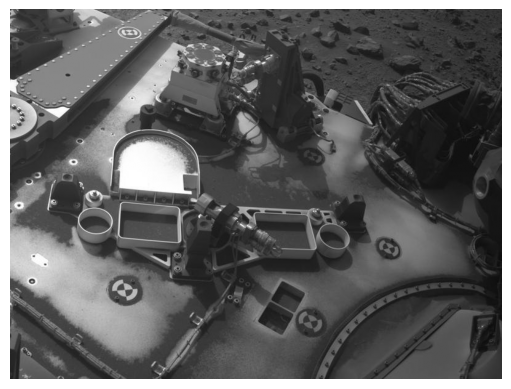

In [ ]:
imgName = f"marsSol1790Left.jpg"

marsImage = loadImageFromDrive(imgName)

show(marsImage, cmap="gray")

In [ ]:
"""
1) Generate and add 5 different noise (including Gaussian and saltand-pepper (impulse)) noise to 3 images. You must be able to specify the noise
mean and variance (for example =10, 0.8) (30 points).
"""
class Noise(object):
    def __init__(self, image: np.ndarray):
        self.image = image.astype(np.float32)
        self.shape = image.shape

    def clip(self, image: np.ndarray):
        L = 255.0
        return np.clip(image, 0, L)

    # --- Gaussian ---
    def addGaussian(self, mean: float, std: float):
        noise = self.clip(np.random.normal(mean, std, self.shape))
        return self.clip(self.image + noise), noise

    # --- Uniform ---
    def addUniform(self, low: float, high: float):
        noise = self.clip(np.random.uniform(low, high, self.shape))
        return self.clip(self.image + noise), noise

    # --- Exponential ---
    def addExponential(self, scale: float):
        noise = self.clip(np.random.exponential(scale, self.shape))
        return self.clip(self.image + noise), noise

    def applySapNoise(self, amount: float, saltVsPepper: float) -> np.ndarray:
        L = 255.0

        amount = float(np.clip(amount, 0.0, 1.0))
        saltVsPepper = float(np.clip(saltVsPepper, 0.0, 1.0))

        outputImage = self.image.copy()

        noise = np.zeros_like(self.image)

        height, width = self.image.shape[:2]
        randomMatrix = np.random.rand(height, width)

        saltProb = amount * saltVsPepper
        pepperProb = amount * (1.0 - saltVsPepper)

        pepperMask = randomMatrix < pepperProb
        saltMask = (randomMatrix >= pepperProb) & (randomMatrix < pepperProb + saltProb)

        outputImage[pepperMask] = 0
        outputImage[saltMask] = L

        noise[pepperMask] = 0
        noise[saltMask] = L

        return outputImage, noise

In [ ]:
class Filters(object):
  def __init__(self, image: np.ndarray):
    self.image = image

  def classicalMedianFilter(self, k: int) -> np.ndarray:
    if k % 2 == 0: raise ValueError(f"k: {k} must be odd")

    output = np.zeros_like(self.image)
    pad = k // 2
    padded = np.pad(self.image, pad, mode='reflect')
    neighborhoods = sliding_window_view(padded, (k, k))

    height, width = neighborhoods.shape[0:2]

    for i in range(height):
        for j in range(width):
            neighborhood = neighborhoods[i, j]
            output[i, j] = np.median(neighborhood)

    return output

  def maxFilter(self, k: int) -> np.ndarray:
    if k % 2 == 0: raise ValueError(f"k: {k} must be odd")

    output = np.zeros_like(self.image)
    pad = k // 2
    padded = np.pad(self.image, pad, mode="reflect")
    neighborhoods = sliding_window_view(padded, (k, k))

    height, width = neighborhoods.shape[0:2]

    for i in range(height):
      for j in range(width):
        neighborhood = neighborhoods[i, j]
        output[i, j] = np.max(neighborhood)

    return output

  def minFilter(self, k: int) -> np.ndarray:
    if k % 2 == 0: raise ValueError(f"k: {k} must be odd")

    output = np.zeros_like(self.image)
    pad = k // 2
    padded = np.pad(self.image, pad, mode="reflect")
    neighborhoods = sliding_window_view(padded, (k, k))

    height, width = neighborhoods.shape[0:2]

    for i in range(height):
      for j in range(width):
        neighborhood = neighborhoods[i, j]
        output[i, j] = np.min(neighborhood)

    return output

  def alphaTrimFilter(self, k: int, d: int) -> np.ndarray:
    if k % 2 == 0: raise ValueError(f"k: {k} must be odd")

    if d % 2 != 0:
        raise ValueError("d must be even (so d/2 can be removed from both sides)")

    n = k * k
    if d >= n:
        raise ValueError("r too large")

    output = np.zeros_like(self.image, dtype=float)
    pad = k // 2
    padded = np.pad(self.image, pad, mode="reflect")
    neighborhoods = sliding_window_view(self.image, (k, k))
    height, width = neighborhoods.shape[0:2]
    trim = d // 2

    for i in range(height):
      for j in range(width):
        neighborhood = neighborhoods[i, j]
        neighborhood = np.sort(neighborhood.flatten())
        trimNair = neighborhood[trim : n - trim]
        output[i, j] = np.mean(trimNair)

    return output

In [ ]:
A = np.array([[51, 212, 124],
              [43, 225, 212],
              [71, 183, 132]], dtype=np.uint8)

filt = Filters(A)
k = 3
print(filt.alphaTrimFilter(k, d=4)[0, 0])

144.4


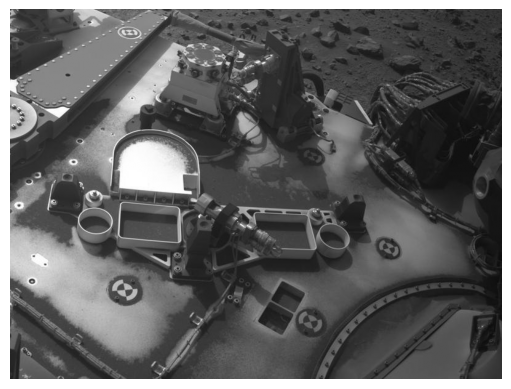

In [ ]:
show(marsImage, cmap="gray")

In [ ]:
# emee filter function
def filter(Imax: float, Imin: float, alpha: float, c: float) -> float:
  Imax = float(Imax)
  Imin = float(Imin)
  c = float(c)
  denominator = np.maximum(Imin + c, 1)
  r = Imax / (denominator)
  # # avoids log(0)
  r = max(r, 1)
  return alpha * (r) ** alpha * np.log(r)

def divideBlock(image: np.ndarray, k1: int, k2: int) -> List[np.ndarray]:
  if image is None:
    print(f"Not valid image")
    return

  height, width = image.shape

  blockHeight = height // k1
  blockWidth = width // k2

  blocks = []

  for i in range(k1):
    for j in range(k2):
      block = image[i * blockHeight: (i + 1) * blockHeight, j * blockWidth: (j + 1) * blockWidth]
      blocks.append(block)

  return blocks

def EMEE(image: np.ndarray, alpha: float, k1: int, k2: int, c: float) -> float:
  quality = 0
  blocks = divideBlock(image, k1, k2)

  blockSize = k1 * k2

  # This version uses too many loops
  # for i in range(blockSize):
  #   Imax = math.float('-inf')
  #   Imin = math.float('inf')

  #   for h in range(len(blocks[i])):
  #     for j in range(len(blocks[i][h])):
  #       Imax = max(Imax, blocks[i][h][j])
  #       Imin = min(Imin, blocks[i][h][j])

  #   quality += filter(Imax, Imin, alpha, c)

  for block in blocks:
    Imax = np.max(block)
    Imin = np.min(block)
    quality += filter(Imax, Imin, alpha, c)

  return (1 / blockSize) * quality

alpha = 0.9
k1, k2 = 8, 8
c = 1

In [ ]:
def sharpening(image: np.ndarray, alpha: float, k: int = 5) -> np.ndarray:
  detail = image - Filters(image).classicalMedianFilter(k)

  sharp = image + ((alpha) * detail)

  return sharp, detail

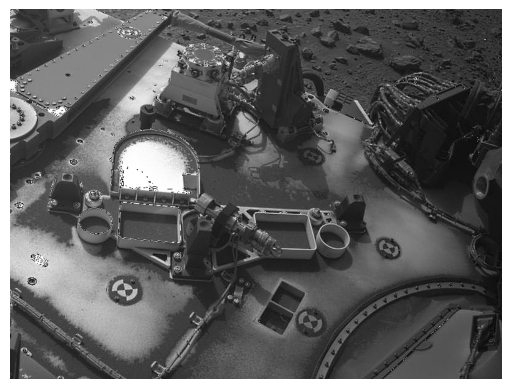

In [ ]:
sharp, detail = sharpening(marsImage, alpha = 1)
show(sharp, cmap="gray")

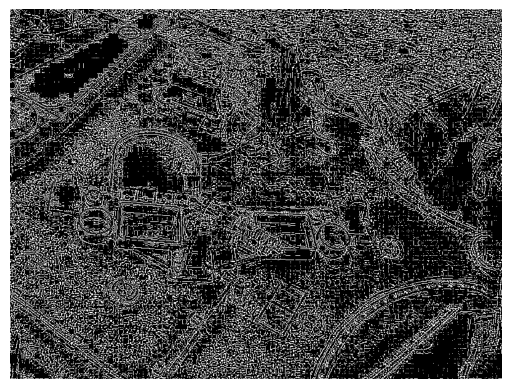

In [ ]:
show(detail, cmap="gray")

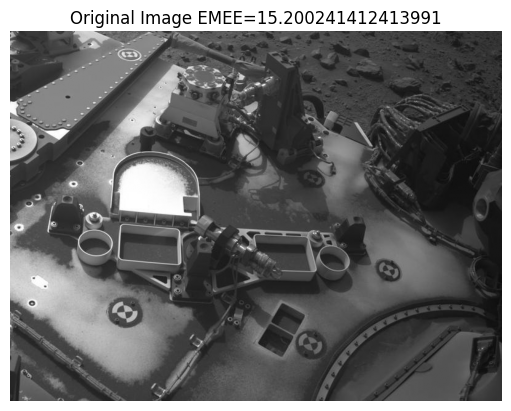

In [ ]:
qualityMeasure = EMEE(marsImage, alpha, k1, k2, c)
show(marsImage, cmap="gray", title=f"Original Image EMEE={qualityMeasure}")

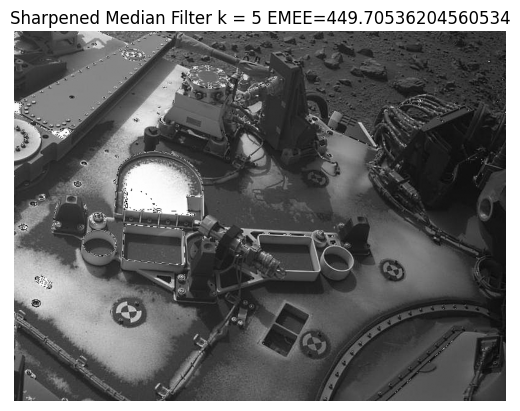

In [ ]:
qualityMeasure = EMEE(sharp, alpha, k1, k2, c)
show(sharp, cmap="gray", title=f"Sharpened Median Filter k = 5 EMEE={qualityMeasure}")

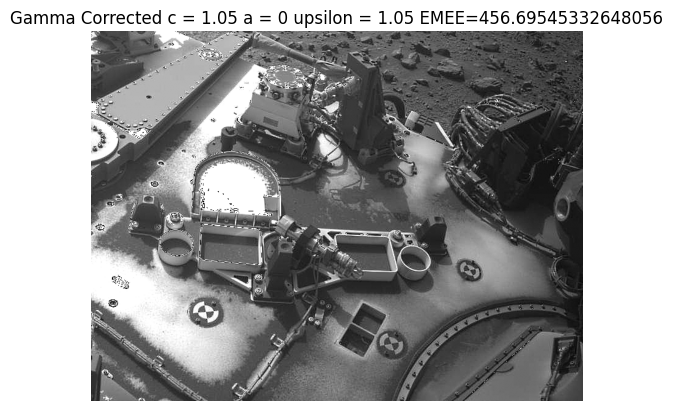

In [ ]:
def gammaFormula(c: float, z: float, a: float, upsilon: float) -> float:
  return c * np.pow((z + a), upsilon)

def gammaCorrection(image: np.ndarray, c: float = 1.2, a: float = 0.0, upsilon: float = 1.0) -> np.ndarray:
  """
  Source: Sos Agaian CSC 475 Slideshow 2 Slide 41

  γ < 1: Expands values of dark pixels compress values of brighter
  pixels
  For γ > 1: Compresses values of dark pixels, expand values of brighter pixels
  If γ=1 & c=1: Identity transformation (s = r)
  """

  z = image.astype(np.float32)

  correctedImage = gammaFormula(c, z, a, upsilon)

  return np.clip(correctedImage, 0, 255).astype(np.uint8)

a = 0
c = 1.05
upsilion = 1.05
gammaCorrected = gammaCorrection(sharp, c=c, a=a, upsilon=upsilion)
qualityMeasure = EMEE(gammaCorrected, alpha, k1, k2, c)
show(gammaCorrected, cmap="gray", title=f"Gamma Corrected c = {c} a = {a} upsilon = {upsilion} EMEE={qualityMeasure}")

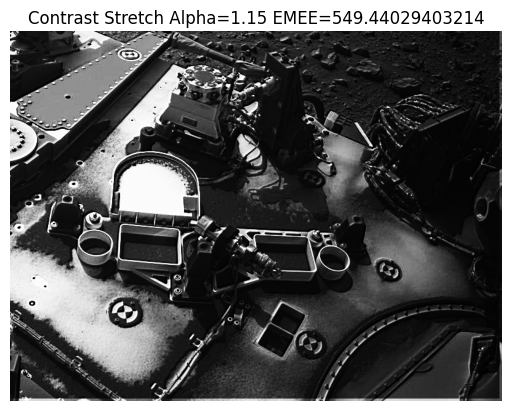

In [ ]:
def constrastFormula(a: float, x: float) -> float:
  return 255.0 / (1 + np.exp(-a * (x - 127.0) / 32.0))

def contrastStretch(image: np.ndarray, a: float) -> np.ndarray:
    x = image.astype(np.float32)

    new_image = constrastFormula(a, x)

    return np.clip(new_image, 0, 255).astype(np.uint8)
a = 1.15
constrast_img = contrastStretch(sharp, a=a)
qualityMeasure = EMEE(constrast_img, alpha, k1, k2, c)
show(constrast_img, cmap="gray", title=f"Contrast Stretch Alpha={a} EMEE={qualityMeasure}")

In [ ]:
mean = 30
std = 20
gaussNoisyImg, gaussNoise = Noise(marsImage).addGaussian(mean=mean, std=std)

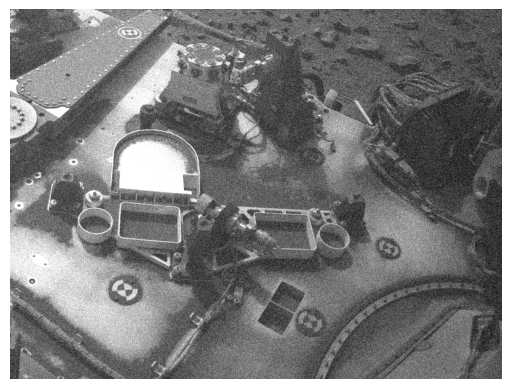

In [ ]:
show(gaussNoisyImg, cmap="gray")

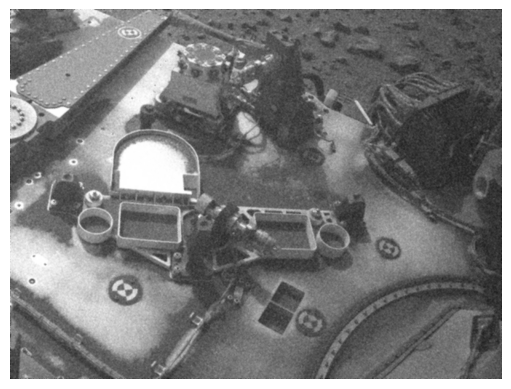

In [ ]:
# Source: chatGPT for fast operations to show on slideshow
def adaptiveRestorationVectorized(noisyImg: np.ndarray, ksize: int) -> np.ndarray:
    """
    Vectorized adaptive local noise reduction filter:
      f̂ = g - (σ_n^2 / max(σ_L^2, σ_n^2)) * (g - μ_L)
    Uses box filtering to compute local mean and local mean of squares.
    """
    if ksize % 2 == 0 or ksize < 3:
        raise ValueError("ksize must be odd and >= 3")

    g = noisyImg.astype(np.float64)

    # Local mean μ_L
    localMean = cv.boxFilter(
        g, ddepth=-1, ksize=(ksize, ksize),
        normalize=True, borderType=cv.BORDER_CONSTANT
    )

    # Local variance σ_L^2 = E[g^2] - (E[g])^2
    localMeanSq = cv.boxFilter(
        g * g, ddepth=-1, ksize=(ksize, ksize),
        normalize=True, borderType=cv.BORDER_CONSTANT
    )
    localVariance = localMeanSq - (localMean * localMean)

    # Noise variance = average of local variance
    noiseVariance = Filters(localVariance).classicalMedianFilter(k=ksize)

    # Ensure local variance isn't below noise variance
    localVariance = np.maximum(localVariance, noiseVariance)

    # Apply adaptive restoration
    localVariance = np.maximum(localVariance, 1e-6)
    noiseRemoved = g - (noiseVariance / localVariance) * (g - localMean)

    return np.clip(noiseRemoved, 0, 255).astype(np.uint8)

adaptiveRestored = adaptiveRestorationVectorized(gaussNoisyImg, ksize=3)

show(adaptiveRestored, cmap="gray")

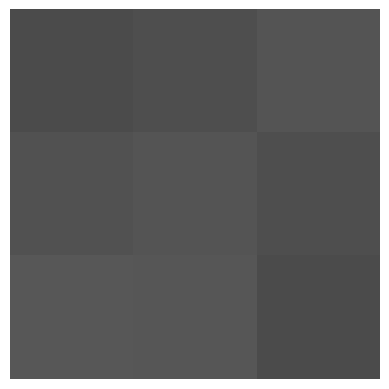

In [ ]:
show(patch(adaptiveRestored, height=250, width=350, ksize=3), cmap="gray")

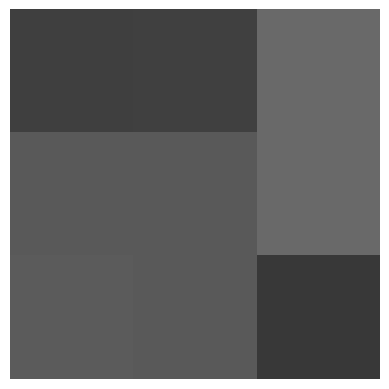

In [ ]:
show(patch(gaussNoisyImg, height=250, width=350, ksize=3), cmap="gray")

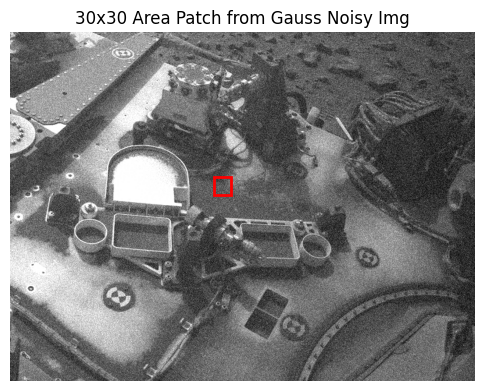

In [ ]:
showHighlight(gaussNoisyImg, height=250, width=350, ksize=30, title="Gauss Noisy Img")